Intro to NumPy

In [119]:
import numpy as np
import matplotlib.pyplot as plt


In [120]:
stock_list = [3.5, 5, 2, 8, 4.2]

returns = np.array(stock_list)
print(returns), type(returns)


[3.5 5.  2.  8.  4.2]


(None, numpy.ndarray)

In [121]:
A = np.array([[1, 2], [3, 4]])

print(A, type(A))


[[1 2]
 [3 4]] <class 'numpy.ndarray'>


In [122]:
print(A.shape)


(2, 2)


In [123]:
print(returns[0], returns[len(returns) - 1])


3.5 4.2


In [124]:
# slicing
print(returns[1:3])


[5. 2.]


In [125]:
""" 
Accessing the first column of a 2-D array
: refers to all of the column, 0 refers to the column (i.e. the first column)
"""
print(A[:, 0]) 


[1 3]


In [126]:
# Accessing the first row of the arrow
print(A[0, :])


[1 2]


In [127]:
# Passing one index to a 2-D array will result in returning the row with the given index 
# This is looking at row 1
print(A[0])


[1 2]


In [128]:
# Like a regular matrix but with zero-indexing
print(A[1, 1])


4


In [129]:
# Array functions
# Takes the log of each element in the array
print(np.log(returns))


[1.25276297 1.60943791 0.69314718 2.07944154 1.43508453]


In [130]:
print(np.mean(returns))


4.54


In [131]:
print(np.max(returns))


8.0


In [132]:
returns * 2 + 5


array([12. , 15. ,  9. , 21. , 13.4])

In [133]:
print("Mean:", np.mean(returns), "Std Dev:", np.std(returns))


Mean: 4.54 Std Dev: 1.9915822855207364


In [134]:
# 10 rows, 100 columns
# zeros() creates a NumPy array with the given dimensions that is entirely filled in with 0
N = 10
assets = np.zeros((N, 100))
returns = np.zeros((N, 100))


In [135]:
R_1 = np.random.normal(1.01, 0.03, 100)
returns[0] = R_1
assets[0] = np.cumprod(R_1)


In [136]:
# Generate assets that are correlated with R_1
for i in range(1, N):
    R_i = R_1 + np.random.normal(0.001, 0.02, 100)
    returns[i] = R_i # Set each row of returns equal to the new R_i array
    assets[i] = np.cumprod(R_i)
    
mean_returns = [(np.mean(R) - 1)*100 for R in returns]
return_volatilities = [np.std(R) for R in returns]


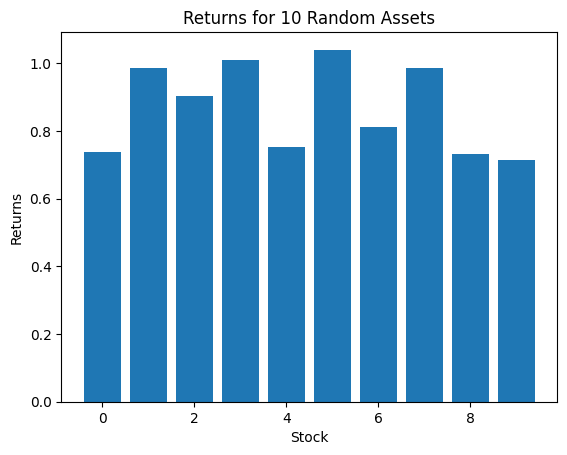

In [137]:
plt.bar(np.arange(len(mean_returns)), mean_returns)
plt.xlabel('Stock')
plt.ylabel('Returns')
plt.title('Returns for {0} Random Assets'.format(N));


In [138]:
weights = np.random.uniform(0, 1, N)
weights = weights/np.sum(weights)


In [139]:
p_returns = np.dot(weights, mean_returns)
print("Expected return of the portfolio:", p_returns)


Expected return of the portfolio: 0.8811442299604344


In [140]:
v = np.array([1, 2, np.nan, 4, 5])
print(v)


[ 1.  2. nan  4.  5.]


In [141]:
print(np.mean(v))


nan


In [ ]:
np.isnan(v)


array([False, False,  True, False, False])

In [ ]:
ix = ~np.isnan(v) # the ~ indicates a Logical not, inverting the bools
print(v[ix])      # we can also just write v = v[~np.isnan(v)]


[1. 2. 4. 5.]


In [144]:
print(np.mean(v[ix]))


3.0


In [146]:
# Shortcut
print(np.nanmean(v))


3.0


In [ ]:
A = np.array([
    [1, 2, 3, 12, 6],
    [4, 5, 6, 15, 20],
    [7, 8, 9, 10, 10]
])

B = np.array([
    [4, 4, 2],
    [2, 3, 1],
    [6, 5, 8],
    [9, 9, 9]
])


(array([[ 1,  2,  3, 12,  6],
        [ 4,  5,  6, 15, 20],
        [ 7,  8,  9, 10, 10]]),
 array([[4, 4, 2],
        [2, 3, 1],
        [6, 5, 8],
        [9, 9, 9]]))

Given an $m \times n$ matrix and a $p \times q$ matrix,
multiplication is only defined when $n = p$.
The resulting matrix has dimensions $m \times q$.
$$(m \times n) \cdot (p \times q) \quad \text{is valid only when} \quad n = p$$

For example, a $3 \times 5$ matrix times a $5 \times 4$ matrix gives a $3 \times 4$ matrix,
but a $3 \times 5$ times a $4 \times 5$ is undefined since $5 \neq 4$.

In [152]:
# print(np.dot(A, B))
# produces an error


These results make sense in accordance with our rule. Multiplying a $3 \times 5$ matrix on the right by a $4 \times 3$ matrix results in an error while multiplying a matrix on the right by a $3 \times 5$ matrix results in a $4 \times 5$ matrix.

In [ ]:
print(np.dot(B, A))


[[ 34  44  54 128 124]
 [ 21  27  33  79  82]
 [ 82 101 120 227 216]
 [108 135 162 333 324]]


#### Portfolio Variance
The variance of a portfolio of $N$ assets is:
$$\sigma_P^2 = \sum_i \omega_i^2\sigma_i^2 + \sum_i\sum_{i \neq j} \omega_i\omega_j\sigma_i\sigma_j\rho_{i,j}$$
- $\omega_i$ = weight of asset $i$
- $\sigma_i^2$ = variance of asset $i$
- $\rho_{i,j}$ = correlation between assets $i$ and $j$

**Why not just sum the individual variances?**
Assets are correlated, so we must account for pairwise covariances.

**Covariance vs Correlation**
Correlation is just normalized covariance, rescaled to always fall between $-1$ and $1$:
$$\rho_{i,j} = \frac{COV[S_i, S_j]}{\sigma_i \sigma_j}$$
Same idea, but correlation is easier to interpret. A covariance of 10,000 is hard to read; a correlation of 0.95 clearly means a strong positive relationship.

**Shorthand using matrix notation:**
$$\sigma_P^2 = \omega \ C \ \omega^\intercal$$
Where $C$ is the $N \times N$ covariance matrix. In NumPy:
```python
var_p = np.dot(np.dot(weights, cov_mat), weights.T)
```

In [156]:
cov_mat = np.cov(returns)
print(cov_mat)


[[0.0009164  0.00102855 0.00100424 0.00092801 0.00097764 0.00097625
  0.00092547 0.00105805 0.00093638 0.00087668]
 [0.00102855 0.00161045 0.00112989 0.00106763 0.00106193 0.00113775
  0.00104494 0.00115351 0.00105271 0.00101468]
 [0.00100424 0.00112989 0.00142651 0.00099239 0.00103505 0.00108536
  0.00097371 0.00124163 0.00107309 0.00101878]
 [0.00092801 0.00106763 0.00099239 0.00145963 0.00095481 0.00109167
  0.0009095  0.00105838 0.00101291 0.00090346]
 [0.00097764 0.00106193 0.00103505 0.00095481 0.00137432 0.00095829
  0.00092177 0.00116045 0.0009527  0.00088266]
 [0.00097625 0.00113775 0.00108536 0.00109167 0.00095829 0.00149271
  0.00101349 0.00113764 0.00106325 0.00095371]
 [0.00092547 0.00104494 0.00097371 0.0009095  0.00092177 0.00101349
  0.00131276 0.00103016 0.0009107  0.00087232]
 [0.00105805 0.00115351 0.00124163 0.00105838 0.00116045 0.00113764
  0.00103016 0.00171478 0.00104255 0.001052  ]
 [0.00093638 0.00105271 0.00107309 0.00101291 0.0009527  0.00106325
  0.0009107 

**The Covariance Matrix $C$**
An $N \times N$ matrix where:
- **Diagonal** entries = each asset's own variance $VAR[S_i]$
- **Off-diagonal** entries = covariance between two assets $COV[S_i, S_j]$

$$C = \begin{bmatrix} VAR[S_1] & COV[S_1,S_2] & \cdots & COV[S_1,S_N] \\ COV[S_2,S_1] & VAR[S_2] & \cdots & COV[S_2,S_N] \\ \vdots & \vdots & \ddots & \vdots \\ COV[S_N,S_1] & COV[S_N,S_2] & \cdots & VAR[S_N] \end{bmatrix}$$

In NumPy: `cov_mat = np.cov(returns)`

**Transpose**
Flipping a matrix by switching its rows and columns.
A $3 \times 5$ matrix transposed becomes $5 \times 3$.
This is why $\omega C \omega^\intercal$ works dimensionally:
$$(1 \times N) \cdot (N \times N) \cdot (N \times 1) = (1 \times 1) = \sigma_P^2$$

In [157]:
print(A)


[[ 1  2  3 12  6]
 [ 4  5  6 15 20]
 [ 7  8  9 10 10]]


In [158]:
print(np.transpose(A))


[[ 1  4  7]
 [ 2  5  8]
 [ 3  6  9]
 [12 15 10]
 [ 6 20 10]]


In [160]:
# INSERT VARIANCES AND COVARIANCES HERE
var_p = np.dot(np.dot(weights, cov_mat), weights.T)
vol_p = np.sqrt(var_p)
print("Portfolio volatility:", vol_p)


Portfolio volatility: 0.03268482095338165
